# wavelets library from [source github page](https://github.com/endolith/wavelets), and with a few fixes due to outdated version of numpy and python, when the library was last modified

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sys import path
path.append('../../wavelet/')
import wavelet_funcs as wf

path.append('../../signals/')
import signals as sg

from wavelets import WaveletAnalysis 

## Example from the [source github page](https://github.com/endolith/wavelets):

In [2]:
dt = 0.1
nt = 1000
x = np.random.randn(nt)
t = np.arange(nt)*dt

wa = WaveletAnalysis(x, dt=dt)

# wavelet power spectrum
power = wa.wavelet_power

# associated time vector
t = wa.time

(<Figure size 1000x400 with 2 Axes>,
 <Axes: >,
 <Axes: >,
 <matplotlib.collections.QuadMesh at 0x162954910>)

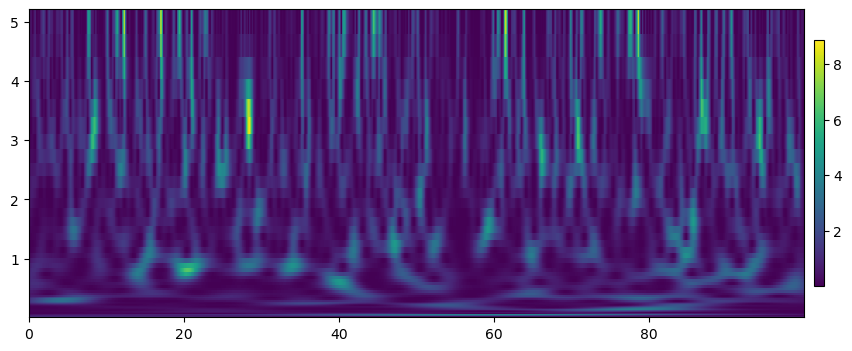

In [3]:
wf.plot_cwt(power, wa.fourier_frequencies, t, add_colorbar=True)

# Two synthetic signals:

$$
s_1 = \cos(2\pi f_1 t) + \epsilon_1,
$$

$$
s_2 = \cos(2\pi f_2 t) + \epsilon_2,
$$

where $f_1=0.02\,$Hz, $f_2=0.04\,$Hz, and $\epsilon_{1,2} \sim N(0, 1)$ (white noise).

In [5]:
T = 1000 # s
dt = 0.5 # s
Fs = 1/dt
nt = int(T/dt)

f1, f2 = 0.1, 0.4 # Hz

t = np.arange(nt)*dt

s1 = sg.cosine(T, f1, sampling_frequency=Fs)[1]# + np.random.randn(nt)
s2 = sg.cosine(T, f2, sampling_frequency=Fs)[1]# + np.random.randn(nt)

In [6]:
w1 = WaveletAnalysis(s1, dt=dt, dj=1/8)
w2 = WaveletAnalysis(s2, dt=dt, dj=1/8)

In [7]:
w1.wavelet_power_spectrum = np.mean(w1.wavelet_power, axis=1)
w2.wavelet_power_spectrum = np.mean(w2.wavelet_power, axis=1)

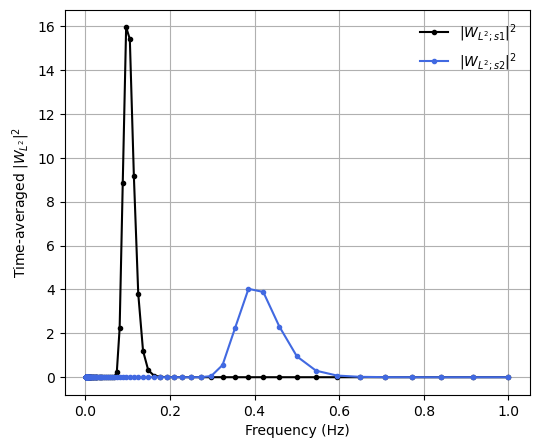

In [8]:
f, ax = plt.subplots(figsize=(6,5))

ax.plot(w1.fourier_frequencies, w1.wavelet_power_spectrum, color='k', marker='.', label=r"$|W_{L^2; s1}|^2$")
ax.plot(w2.fourier_frequencies, w2.wavelet_power_spectrum, color='royalblue', marker='.', label=r"$|W_{L^2; s2}|^2$")
ax.legend(frameon=False)
ax.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|W_{L^2}|^2$')
ax.grid()

## Compute power According to Equation 24 in TC98:

$$
P = \frac{\delta j \, \delta t}{C_\delta} \sum_{j=j_1}^{j_2} \frac{|W(s_j)|^2}{s_j}
$$

In [30]:
def power_from_1d_spectrum(w):
    p = w.global_wavelet_spectrum * w.data_variance # Because 'global_wavelet_spectrum' func normalizes by data variance, which is not written in Eq. 24 in the paper
    coef = w.dj * w.dt / w.compute_Cdelta().item().real
    return ( coef * np.sum( p / w.scales ) ).item()

In [31]:
print(f'Integral of wavelet power of 0.1-Hz cosine: {power_from_1d_spectrum(w1):.5f}')
print(f'Integral of wavelet power of 0.4-Hz cosine: {power_from_1d_spectrum(w2):.5f}')

Integral of wavelet power of 0.1-Hz cosine: 1.64796
Integral of wavelet power of 0.4-Hz cosine: 1.55893


The integral of wavelet power of the 0.4-Hz cosine is a bit higher than that of 0.1-Hz cosine. The higher the frequency difference, the higher the difference between the integrals. It doesn't seem to change if sampling frequency is increased 50-fold.

## Same signals but with noise

In [69]:
T = 10000 # s
dt = 0.5 # s
Fs = 1/dt
nt = int(T/dt)

f1, f2 = 0.1, 0.4 # Hz

t = np.arange(nt)*dt

In [70]:
s1 = sg.cosine(T, f1, sampling_frequency=Fs)[1] + np.random.randn(nt)
s2 = sg.cosine(T, f2, sampling_frequency=Fs)[1] + np.random.randn(nt)

In [71]:
w1 = WaveletAnalysis(s1, dt=dt, dj=1/32)
w2 = WaveletAnalysis(s2, dt=dt, dj=1/32)

In [72]:
w1.wavelet_power_spectrum = np.mean(w1.wavelet_power, axis=1)
w2.wavelet_power_spectrum = np.mean(w2.wavelet_power, axis=1)

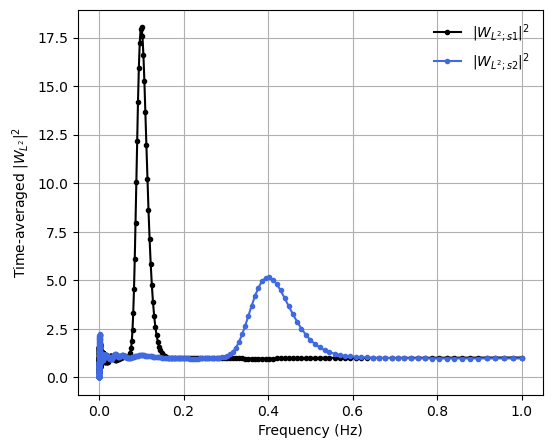

In [73]:
f, ax = plt.subplots(figsize=(6,5))

ax.plot(w1.fourier_frequencies, w1.wavelet_power_spectrum, color='k', marker='.', label=r"$|W_{L^2; s1}|^2$")
ax.plot(w2.fourier_frequencies, w2.wavelet_power_spectrum, color='royalblue', marker='.', label=r"$|W_{L^2; s2}|^2$")
ax.legend(frameon=False)
ax.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|W_{L^2}|^2$')
ax.grid()

In [74]:
print(f'Integral of wavelet power of 0.1-Hz cosine: {power_from_1d_spectrum(w1):.5f}')
print(f'Integral of wavelet power of 0.4-Hz cosine: {power_from_1d_spectrum(w2):.5f}')

Integral of wavelet power of 0.1-Hz cosine: 1.59404
Integral of wavelet power of 0.4-Hz cosine: 1.58299


Integrals are almost the same (slight difference due to noise, small bias shown above with noiseless signals). This seems strange because we are summing $|W|^2$ (which has a peak standing on a constant background) divided by $s$. I.e., we are integrating a value $\propto 1/s \propto f$. But we are not integrating ($\delta j = const$, not a scale step...). I need to study Eq. 24 of TC98 more and how it relates to integrating $|W_{L^1}|^2/f$, done in this [notebook](https://github.com/Maliboue/time_freq_lib/blob/main/examples/cwt_via_matlab/cwt_Amplitude_vs_Scale_sumCosines_and_how_to_get_BandIntegratedPower.ipynb).

Integrate spectrum ($|W|^2$) over frequencies:

In [75]:
np.trapezoid(w1.global_wavelet_spectrum[::-1] * w1.data_variance, w1.fourier_frequencies[::-1])

np.float64(1.5128700070155743)

In [76]:
np.trapezoid(w2.global_wavelet_spectrum[::-1] * w2.data_variance, w2.fourier_frequencies[::-1])

np.float64(1.5028364699286352)

Integrating $|W_{L^2}|^2$ over frequency does not depend on cosine oscillation frequency

## Plot $|W_{L^2}|^2/s$

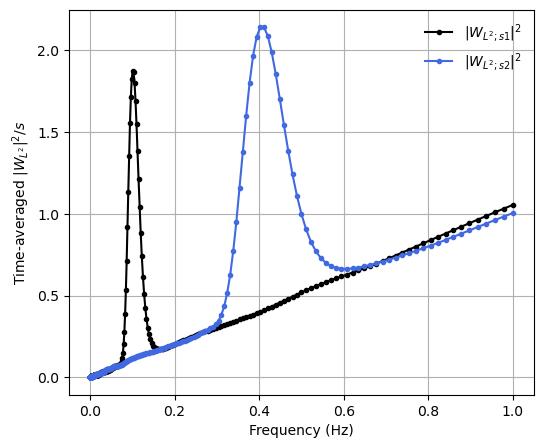

In [77]:
f, ax = plt.subplots(figsize=(6,5))

ax.plot(w1.fourier_frequencies, w1.wavelet_power_spectrum/w1.scales, color='k', marker='.', label=r"$|W_{L^2; s1}|^2$")
ax.plot(w2.fourier_frequencies, w2.wavelet_power_spectrum/w2.scales, color='royalblue', marker='.', label=r"$|W_{L^2; s2}|^2$")
ax.legend(frameon=False)
ax.set(xlabel='Frequency (Hz)', ylabel = r'Time-averaged $|W_{L^2}|^2/s$')
ax.grid()

In [78]:
(w1.wavelet_power_spectrum/w1.scales).sum()

np.float64(72.67887528030477)

In [79]:
(w2.wavelet_power_spectrum/w2.scales).sum()

np.float64(72.17523402321613)

# Summing $|W_{L^2}|^2/s$ does not depend on cosine oscillation frequency... What is the connection to integration of $|W_{L^2}|^2$ done above?

----

## Check if integrated power scales as amplitude squared

In [85]:
amps = np.arange(1, 21, 3)
signals = [sg.cosine(T, 0.1, Fs, amplitude=amp)[1] for amp in amps]

(1000.0, 1400.0)

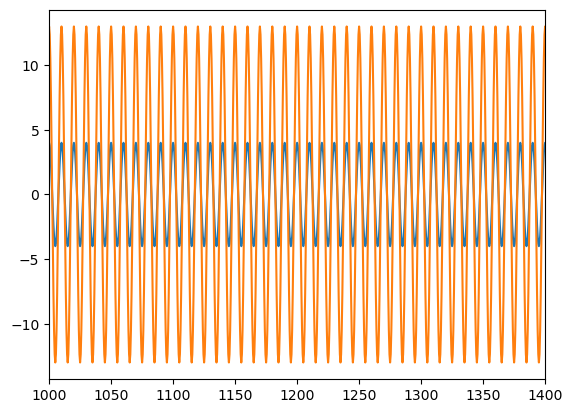

In [86]:
plt.plot(t, signals[1], t, signals[4])
plt.xlim(1000, 1400)

In [87]:
cwts = [WaveletAnalysis(s, dt=dt) for s in signals]
cwt_pows = [r.global_wavelet_spectrum * r.data_variance for r in cwts]

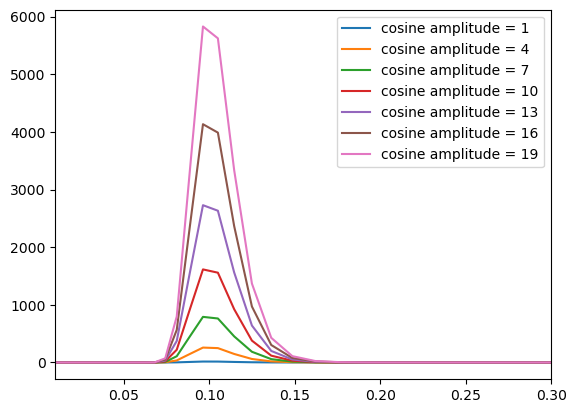

In [91]:
for r, a in zip(cwt_pows, amps):
    plt.plot(cwts[0].fourier_frequencies, r, label=f"cosine amplitude = {a}")
plt.xlim(0.01, 0.3)
plt.legend()

In [93]:
band_powers = [power_from_1d_spectrum(r) for r in cwts]

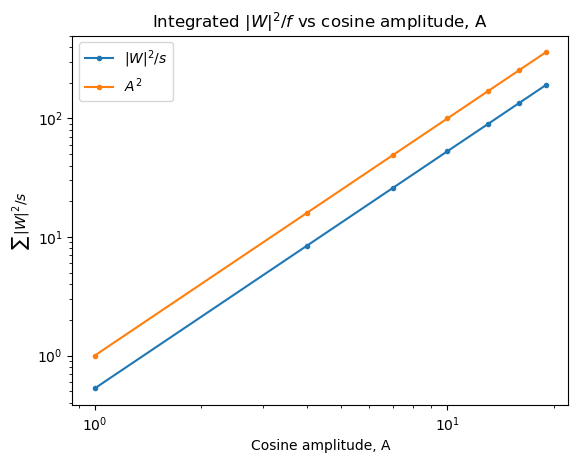

In [97]:
f, ax = plt.subplots()
ax.loglog(amps, band_powers, label='$|W|^2/s$', marker='.')
ax.loglog(amps, np.array(amps)**2, label='$A^2$', marker='.')
ax.set(ylabel='$\sum \,|W|^2/s$',
       xlabel='Cosine amplitude, A',
       title='Integrated $|W|^2/f$ vs cosine amplitude, A',
      )
ax.legend()

In [96]:
band_powers

[0.5286237028699237,
 8.457979245918779,
 25.90256144062626,
 52.86237028699238,
 89.33740578501708,
 135.32766793470046,
 190.83315673604247]

### This integrated $|W|^2/s$ scales as squared amplitude of oscillation, as power of cosine does. This simply confirms that (band-)integrated $|W|^2/s$ is proportional to signal's power in a frequency band.